In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
labels = pd.read_csv(r"C:\Research_Paper_Project\Project\results\labels.csv")

print(labels.head())
print(labels.columns)

   Subtype
0        0
1        0
2        1
3        0
4        1
Index(['Subtype'], dtype='object')


In [6]:
labels = pd.read_csv(r"C:\Research_Paper_Project\Project\results\labels.csv")

y = labels["Subtype"]

In [7]:
X = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\clean_dataset.csv",
    index_col=0
)

In [8]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(141, 29873)
(141,)
Subtype
0    41
1    30
3    30
2    29
4    11
Name: count, dtype: int64


In [9]:
labels = pd.read_csv(r"C:\Research_Paper_Project\Project\results\labels.csv")
print(labels.head())
print(labels.columns)

   Subtype
0        0
1        0
2        1
3        0
4        1
Index(['Subtype'], dtype='object')


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

In [12]:
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)

pca_df["Subtype"] = y

pca_df.head()

,PC1,PC2,Subtype
0,-87.162409,77.040692,0
1,-66.621487,60.621797,0
2,-16.712700,-22.509450,1
3,-74.366734,98.712913,0
4,-47.595114,-9.234084,1


In [13]:
print("Explained Variance")

print(pca.explained_variance_ratio_)

Explained Variance
[0.14057667 0.09382278]


In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [16]:
label_map = {
    0: "Basal",
    1: "Her2",
    2: "Luminal A",
    3: "Luminal B",
    4: "Normal"
}

y = labels["Subtype"].map(label_map)

print(y.head())

0    Basal
1    Basal
2     Her2
3    Basal
4     Her2
Name: Subtype, dtype: object


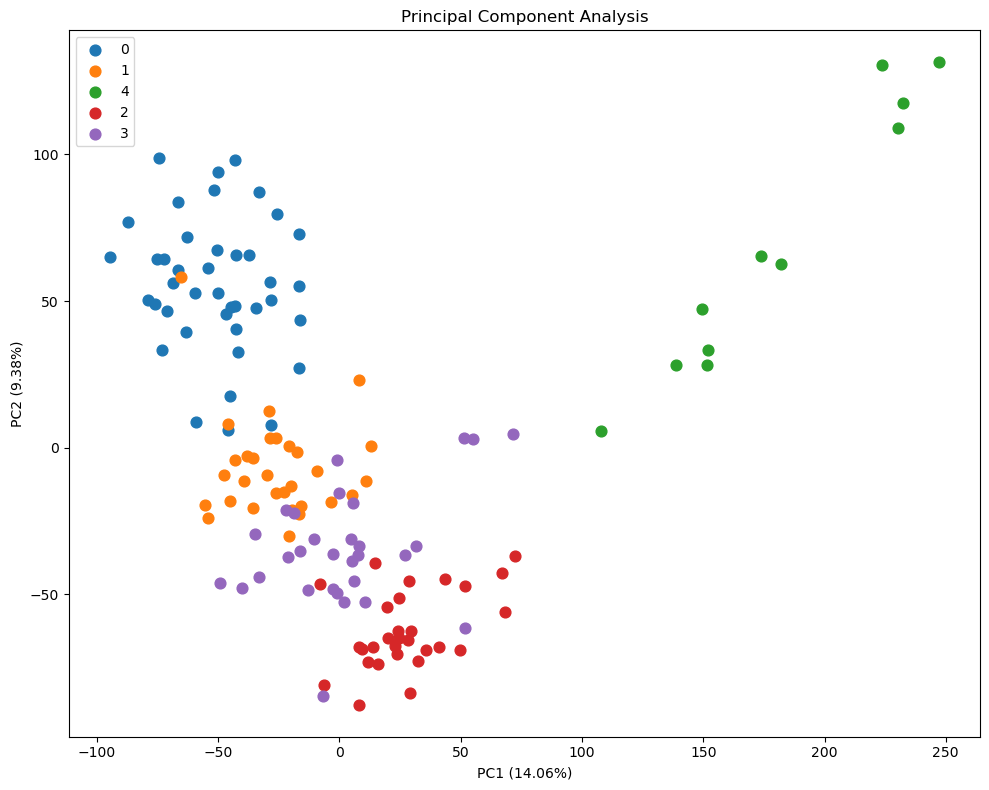

In [19]:
plt.figure(figsize=(10,8))

for subtype in pca_df["Subtype"].unique():

    subset = pca_df[pca_df["Subtype"] == subtype]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=subtype,
        s=60
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

plt.title("Principal Component Analysis")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/PCA_plot.png",
    dpi=300
)

plt.show()

In [15]:
pca_df.to_csv(
    "results/PCA_coordinates.csv",
    index=False
)

print("PCA Saved")

PCA Saved


In [21]:
import seaborn as sns

# Get all genes from the dataset
gene_list = X.columns.tolist()

# Create heatmap data with all genes
heatmap_data = X[gene_list]

In [25]:
import os

print(os.path.exists(r"C:\Research_Paper_Project\Project\results\top_genes.csv"))

False


In [27]:
import pandas as pd

top_genes = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\top_ranked_genes.csv"
)

print(top_genes.head())
print(top_genes.columns)

      Probe_ID     F_Score
0    211565_at  481.216276
1  243689_s_at  297.991104
2   1562755_at  276.654465
3    220232_at  208.893237
4    233103_at  204.729457
Index(['Probe_ID', 'F_Score'], dtype='object')


In [28]:
print(top_genes.columns)

top_genes.head()

Index(['Probe_ID', 'F_Score'], dtype='object')


,Probe_ID,F_Score
0,211565_at,481.216276
1,243689_s_at,297.991104
2,1562755_at,276.654465
3,220232_at,208.893237
4,233103_at,204.729457


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load expression dataset
X = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\clean_dataset.csv",
    index_col=0
)

# Load top genes
top_genes = pd.read_csv(
    r"C:\Research_Paper_Project\Project\results\top_ranked_genes.csv"
)

# Select top 50 probe IDs
probe_list = top_genes["Probe_ID"].head(50).tolist()

# Keep only probes that exist in dataset
probe_list = [p for p in probe_list if p in X.columns]

heatmap_data = X[probe_list]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=heatmap_data.columns,
    index=heatmap_data.index
)

<Figure size 1600x1000 with 0 Axes>

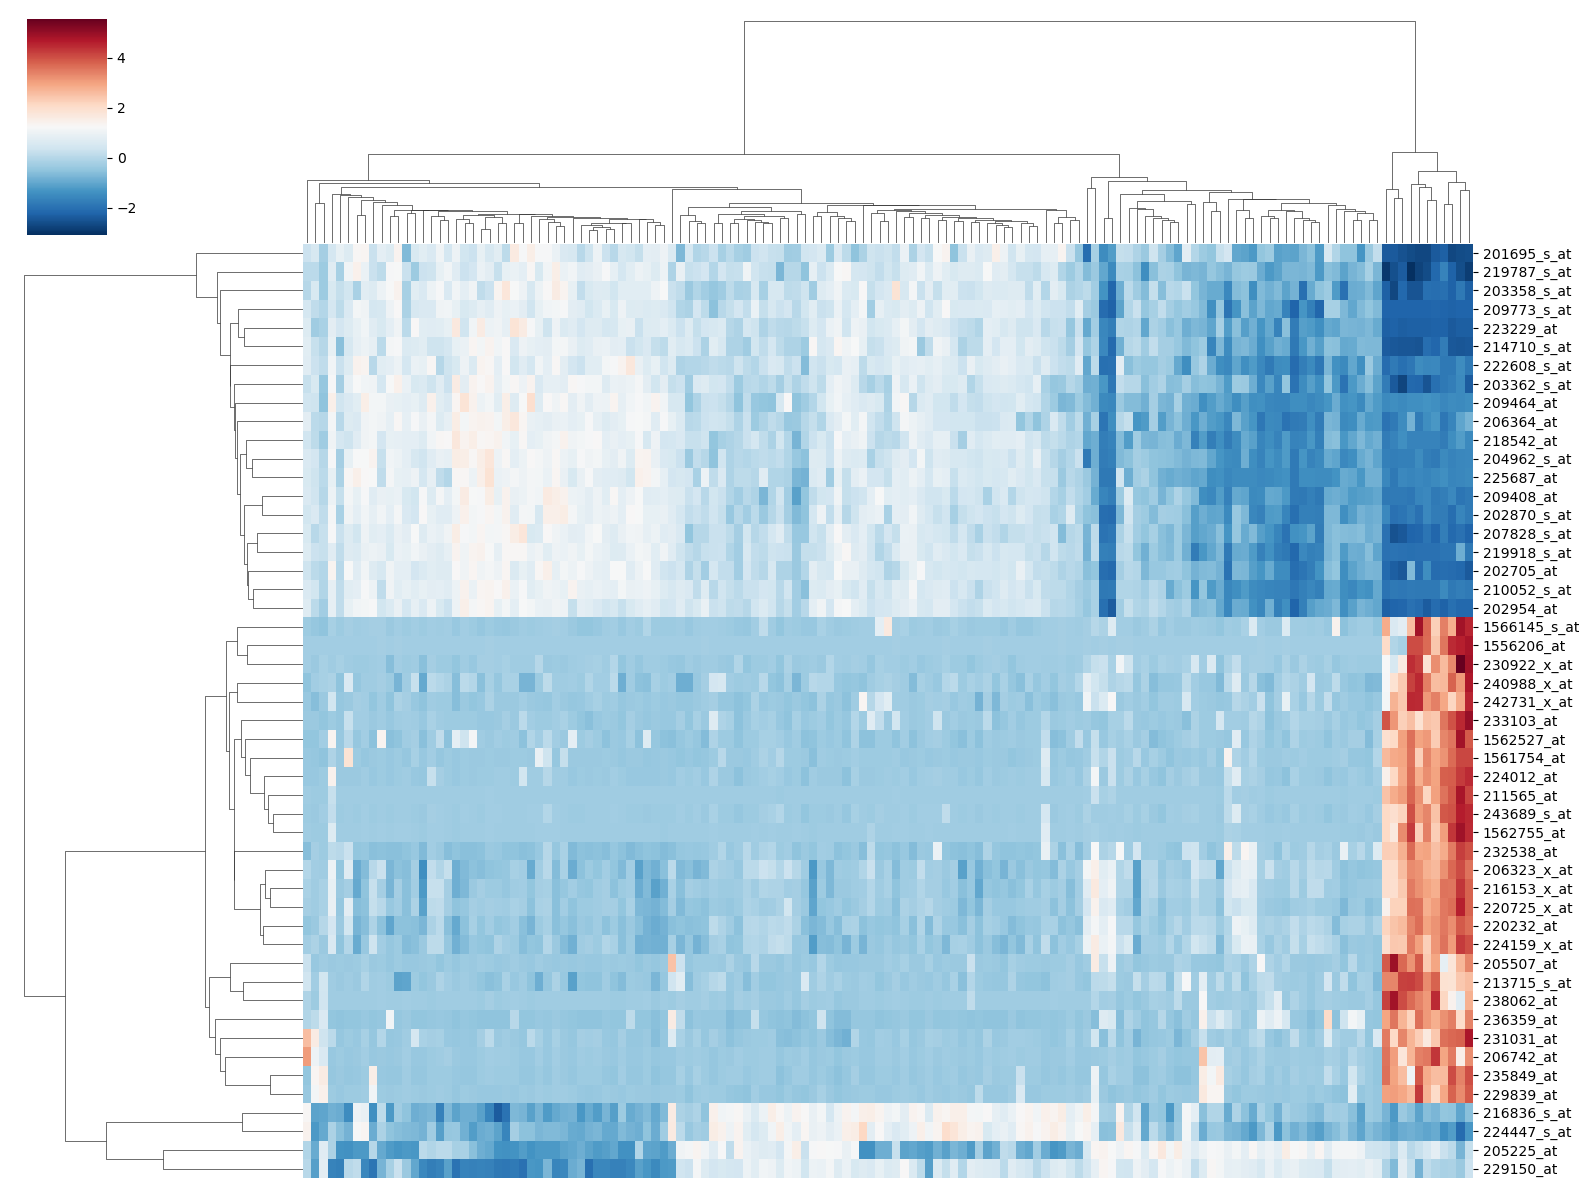

In [33]:
plt.figure(figsize=(16,10))

sns.clustermap(
    heatmap_scaled.T,
    cmap="RdBu_r",
    figsize=(16,12),
    xticklabels=False,
    yticklabels=True
)

plt.savefig(
    r"C:\Research_Paper_Project\Project\figures\Heatmap_Top50Genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()